# 05 — Ecommify: Pruebas de Carga, Concurrencia y Escalabilidad

**Equipo:** Fredy O. Pulido · Myriam A. Martinez · Nicolas F. Torres · Juan F. Perez

**Prerrequisito**: Notebooks 01-04 ejecutados (esquema, datos y ETL listos).

## Objetivo

Ejecutar un harness de carga **único y reusado** para PostgreSQL (Supabase) y MongoDB (Atlas), de forma que las métricas sean directamente comparables: mismo formato, misma metodología, mismas unidades.

## Qué mide este notebook

1. **Concurrencia**: throughput y latencia (p50/p95/p99) a 1, 5, 10, 15, 20 y 30 clientes simultáneos.
2. **Tipos de query**: punto (lookup por ID) vs. compleja (JOIN/aggregation tipo dashboard).
3. **Escalabilidad de dataset**: mismo query sobre subconjuntos crecientes (2016 → 2016-17 → 2016-18), aprovechando las particiones RANGE ya creadas.
4. **Punto de quiebre**: concurrencia donde aparecen errores o la latencia se degrada >3x respecto al baseline.

## ⚠️ Nota sobre límites del free tier

Supabase pooler limita a ~60 conexiones, Atlas M0 a 100. Ambos comparten CPU/RAM (burst). Es esperable observar degradación más temprana que en un ambiente de producción dedicado — esto es en sí mismo un hallazgo válido a documentar en el informe técnico, no un error del diseño.

# Conexion al Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Instalar dependencias

In [2]:
!pip install --quiet psycopg2-binary 'pymongo[srv]' pandas matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 63.4 MB/s eta 0:00:00


## 2. Conexión a ambas bases de datos

In [3]:
import getpass, time, json, os
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor

import psycopg2
from psycopg2 import pool as pg_pool
from psycopg2.extras import RealDictCursor
from pymongo import MongoClient
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata


SUPABASE_URI = userdata.get('SUPABASE_URI')
ATLAS_URI    = userdata.get('ATLAS_URI')

# Pool de conexiones PG — necesario porque cada hilo requiere su propia conexión
# (psycopg2 NO es thread-safe a nivel de conexion individual)
PG_POOL = pg_pool.ThreadedConnectionPool(
    minconn=2, maxconn=35, dsn=SUPABASE_URI,
    options='-c statement_timeout=30000'
)

# MongoClient SI es thread-safe; un solo cliente compartido basta
MC = MongoClient(ATLAS_URI, maxPoolSize=50, serverSelectionTimeoutMS=10000)
DB = MC['ecommify']

os.makedirs('/content/drive/MyDrive/Colab Notebooks/MaestriaArch-OBD-U5/evidencias', exist_ok=True)
TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')

# Verificacion rapida
conn = PG_POOL.getconn()
with conn.cursor() as cur:
    cur.execute('SELECT COUNT(*) FROM orders')
    n_orders = cur.fetchone()[0]
PG_POOL.putconn(conn)
n_mdb = DB.orders_summary.count_documents({})

print('Conexiones OK')
print('  PostgreSQL orders:        {:,}'.format(n_orders))
print('  MongoDB orders_summary:   {:,}'.format(n_mdb))
print('  Timestamp run: ' + TIMESTAMP)

Conexiones OK
  PostgreSQL orders:        191,648
  MongoDB orders_summary:   191,648
  Timestamp run: 20260621_011737


## 3. Harness de carga unico (reusado para PG y MongoDB)

Esta es la pieza central: el mismo `run_load_test()` se usa para ambos motores. Esto garantiza que throughput, p50/p95/p99 y error rate se calculan exactamente igual en ambos lados.

In [4]:
def run_load_test(operation_fn, concurrency, duration_s=10):
    """
    Ejecuta operation_fn() repetidamente desde `concurrency` hilos durante duration_s segundos.
    Retorna throughput, percentiles de latencia y tasa de error.
    """
    latencies_ms = []
    errors = [0]
    stop_at = time.time() + duration_s
    lock_results = []

    def worker():
        local_lat = []
        local_err = 0
        while time.time() < stop_at:
            t0 = time.time()
            try:
                operation_fn()
                local_lat.append((time.time() - t0) * 1000)
            except Exception:
                local_err += 1
        return local_lat, local_err

    with ThreadPoolExecutor(max_workers=concurrency) as ex:
        futures = [ex.submit(worker) for _ in range(concurrency)]
        for f in futures:
            lat, err = f.result()
            latencies_ms.extend(lat)
            errors[0] += err

    total_ops = len(latencies_ms)
    if total_ops == 0:
        return {'concurrency': concurrency, 'throughput_ops_s': 0, 'p50_ms': None,
                'p95_ms': None, 'p99_ms': None, 'errors': errors[0], 'total_ops': 0}

    arr = np.array(latencies_ms)
    return {
        'concurrency': concurrency,
        'throughput_ops_s': round(total_ops / duration_s, 2),
        'p50_ms': round(float(np.percentile(arr, 50)), 2),
        'p95_ms': round(float(np.percentile(arr, 95)), 2),
        'p99_ms': round(float(np.percentile(arr, 99)), 2),
        'errors': errors[0],
        'total_ops': total_ops,
    }

print('Harness listo: run_load_test(operation_fn, concurrency, duration_s)')

Harness listo: run_load_test(operation_fn, concurrency, duration_s)


## 4. Obtener muestra de IDs para parametrizar queries

Usamos order_id/customer_state reales (no fijos) en cada llamada para evitar sesgo por cache de un único valor repetido.

In [5]:
conn = PG_POOL.getconn()
with conn.cursor() as cur:
    cur.execute('SELECT order_id FROM orders ORDER BY random() LIMIT 500')
    SAMPLE_ORDER_IDS_PG = [r[0] for r in cur.fetchall()]
PG_POOL.putconn(conn)

SAMPLE_ORDER_IDS_MDB = [d['_id'] for d in DB.orders_summary.aggregate([
    {'$sample': {'size': 500}}, {'$project': {'_id': 1}}
])]

ESTADOS_BR = ['SP', 'RJ', 'MG', 'RS', 'PR', 'SC', 'BA', 'GO']

print('Muestras listas:')
print('  PG order_ids:   {}'.format(len(SAMPLE_ORDER_IDS_PG)))
print('  MDB order_ids:  {}'.format(len(SAMPLE_ORDER_IDS_MDB)))

Muestras listas:
  PG order_ids:   500
  MDB order_ids:  500


## 5. Definición de queries — Punto vs Compleja

**Punto**: lookup directo por order_id. Nota: `orders` está particionada por `order_purchase_timestamp`, y este lookup NO incluye la columna de partición — fuerza un escaneo de TODAS las particiones. Esto es intencional: es un hallazgo real sobre el trade-off del particionamiento que se documentará en el informe técnico.

**Compleja**: JOIN/aggregation tipo dashboard (ventas por estado en un rango de fechas).

In [6]:
import random

# ── PostgreSQL: Query de PUNTO ──
def pg_point_query():
    conn = PG_POOL.getconn()
    try:
        with conn.cursor() as cur:
            oid = random.choice(SAMPLE_ORDER_IDS_PG)
            cur.execute('SELECT order_id, order_status FROM orders WHERE order_id = %s', (oid,))
            cur.fetchall()
    finally:
        PG_POOL.putconn(conn)

# ── PostgreSQL: Query COMPLEJA (dashboard) ──
def pg_complex_query():
    conn = PG_POOL.getconn()
    try:
        with conn.cursor() as cur:
            estado = random.choice(ESTADOS_BR)
            cur.execute("""
                SELECT c.customer_state, COUNT(DISTINCT o.order_id) as orders,
                       SUM(op.payment_value) as total
                FROM orders o
                JOIN customers c ON c.customer_id = o.customer_id
                JOIN order_payments op ON op.order_id = o.order_id
                                       AND op.order_purchase_timestamp = o.order_purchase_timestamp
                WHERE c.customer_state = %s
                  AND o.order_purchase_timestamp >= '2018-01-01'
                GROUP BY c.customer_state
            """, (estado,))
            cur.fetchall()
    finally:
        PG_POOL.putconn(conn)

# ── MongoDB: Query de PUNTO ──
def mdb_point_query():
    oid = random.choice(SAMPLE_ORDER_IDS_MDB)
    DB.orders_summary.find_one({'_id': oid})

# ── MongoDB: Query COMPLEJA (aggregation tipo dashboard) ──
def mdb_complex_query():
    estado = random.choice(ESTADOS_BR)
    list(DB.orders_summary.aggregate([
        {'$match': {'customer.state': estado,
                    'purchase_date': {'$gte': datetime(2018, 1, 1)}}},
        {'$group': {'_id': '$customer.state',
                    'orders': {'$sum': 1},
                    'total': {'$sum': '$payment_total'}}}
    ]))

print('4 funciones de query definidas: pg_point, pg_complex, mdb_point, mdb_complex')

4 funciones de query definidas: pg_point, pg_complex, mdb_point, mdb_complex


## 6. Matriz de pruebas de concurrencia

Niveles: 1, 5, 10, 15, 20, 30 clientes simultáneos × 4 combinaciones (PG/MDB × punto/compleja).

Duración por punto: 10 segundos. Tiempo total estimado: ~6-8 minutos.

In [7]:
CONCURRENCY_LEVELS = [1, 5, 10, 15, 20, 30]
DURATION_S = 10

resultados_concurrencia = []

queries_a_probar = [
    ('PostgreSQL', 'punto',    pg_point_query),
    ('PostgreSQL', 'compleja', pg_complex_query),
    ('MongoDB',    'punto',    mdb_point_query),
    ('MongoDB',    'compleja', mdb_complex_query),
]

for motor, tipo, fn in queries_a_probar:
    print('\n=== {} — {} ==='.format(motor, tipo))
    for c in CONCURRENCY_LEVELS:
        r = run_load_test(fn, concurrency=c, duration_s=DURATION_S)
        r['motor'] = motor
        r['tipo_query'] = tipo
        resultados_concurrencia.append(r)
        print('  c={:3d}  throughput={:8.1f} ops/s  p50={:7.1f}ms  p95={:7.1f}ms  p99={:7.1f}ms  errors={}'.format(
            c, r['throughput_ops_s'], r['p50_ms'] or 0, r['p95_ms'] or 0, r['p99_ms'] or 0, r['errors']))

df_concurrencia = pd.DataFrame(resultados_concurrencia)
print('\nMatriz de concurrencia completada: {} corridas'.format(len(df_concurrencia)))


=== PostgreSQL — punto ===
  c=  1  throughput=     2.0 ops/s  p50=  521.3ms  p95=  526.6ms  p99=  530.4ms  errors=0
  c=  5  throughput=     3.5 ops/s  p50= 1569.3ms  p95= 3725.9ms  p99= 3845.8ms  errors=0
  c= 10  throughput=     2.2 ops/s  p50= 1643.9ms  p95= 9978.0ms  p99=10129.0ms  errors=0
  c= 15  throughput=     1.5 ops/s  p50=13988.4ms  p95=13988.7ms  p99=13988.8ms  errors=0
  c= 20  throughput=     1.5 ops/s  p50=19275.0ms  p95=19275.4ms  p99=19275.7ms  errors=5
  c= 30  throughput=     1.5 ops/s  p50=29623.0ms  p95=29623.6ms  p99=29623.7ms  errors=15

=== PostgreSQL — compleja ===
  c=  1  throughput=     1.3 ops/s  p50=  556.1ms  p95= 1665.4ms  p99= 2671.4ms  errors=0
  c=  5  throughput=     4.4 ops/s  p50=  862.5ms  p95= 3633.6ms  p99= 3930.2ms  errors=0
  c= 10  throughput=     1.9 ops/s  p50= 8607.8ms  p95=10179.8ms  p99=10304.4ms  errors=0
  c= 15  throughput=     1.5 ops/s  p50=14021.5ms  p95=14032.3ms  p99=14051.9ms  errors=0
  c= 20  throughput=     1.5 ops/s  p50=

## 7. Identificar punto de quiebre

Punto de quiebre = primer nivel de concurrencia donde aparecen errores, o donde p95 supera 3x el p95 del baseline (concurrencia=1).

In [8]:
def encontrar_punto_quiebre(df, motor, tipo):
    sub = df[(df['motor'] == motor) & (df['tipo_query'] == tipo)].sort_values('concurrency')
    baseline = sub[sub['concurrency'] == 1]['p95_ms'].values
    if len(baseline) == 0 or baseline[0] is None:
        return None
    umbral = baseline[0] * 3
    for _, row in sub.iterrows():
        if row['errors'] > 0:
            return {'concurrency': row['concurrency'], 'razon': 'errores presentes'}
        if row['p95_ms'] is not None and row['p95_ms'] > umbral:
            return {'concurrency': row['concurrency'],
                    'razon': 'p95 > 3x baseline ({:.0f}ms)'.format(umbral)}
    return {'concurrency': None, 'razon': 'sin degradacion significativa en el rango probado'}

print('=== Puntos de quiebre identificados ===\n')
puntos_quiebre = []
for motor, tipo, _ in queries_a_probar:
    pq = encontrar_punto_quiebre(df_concurrencia, motor, tipo)
    pq['motor'] = motor
    pq['tipo_query'] = tipo
    puntos_quiebre.append(pq)
    print('  {} / {}: concurrencia={}  ({})'.format(motor, tipo, pq['concurrency'], pq['razon']))

df_quiebre = pd.DataFrame(puntos_quiebre)

=== Puntos de quiebre identificados ===

  PostgreSQL / punto: concurrencia=5  (p95 > 3x baseline (1580ms))
  PostgreSQL / compleja: concurrencia=10  (p95 > 3x baseline (4996ms))
  MongoDB / punto: concurrencia=None  (sin degradacion significativa en el rango probado)
  MongoDB / compleja: concurrencia=20  (p95 > 3x baseline (938ms))


## 8. Pruebas de escalabilidad — dataset creciente

Aprovechamos las particiones RANGE ya creadas en `orders` como proxy de "dataset creciente":

- **Subconjunto A**: solo 2016 (partición más pequeña)
- **Subconjunto B**: 2016 + 2017
- **Subconjunto C**: 2016 + 2017 + 2018 (dataset completo, ~99K órdenes)

Se mide el mismo aggregation (ventas totales agrupadas por estado) sobre cada subconjunto, a concurrencia fija de 10 clientes.

In [9]:
SUBCONJUNTOS = [
    ('A_2016',      '2016-01-01', '2017-01-01'),
    ('B_2016_2017', '2016-01-01', '2018-01-01'),
    ('C_completo',  '2016-01-01', '2019-01-01'),
]

def pg_scalability_query(fecha_ini, fecha_fin):
    def _fn():
        conn = PG_POOL.getconn()
        try:
            with conn.cursor() as cur:
                cur.execute("""
                    SELECT c.customer_state, COUNT(*) as n, SUM(op.payment_value) as total
                    FROM orders o
                    JOIN customers c ON c.customer_id = o.customer_id
                    JOIN order_payments op ON op.order_id = o.order_id
                                           AND op.order_purchase_timestamp = o.order_purchase_timestamp
                    WHERE o.order_purchase_timestamp >= %s AND o.order_purchase_timestamp < %s
                    GROUP BY c.customer_state
                """, (fecha_ini, fecha_fin))
                cur.fetchall()
        finally:
            PG_POOL.putconn(conn)
    return _fn

def mdb_scalability_query(fecha_ini, fecha_fin):
    di = datetime.strptime(fecha_ini, '%Y-%m-%d')
    df_ = datetime.strptime(fecha_fin, '%Y-%m-%d')
    def _fn():
        list(DB.orders_summary.aggregate([
            {'$match': {'purchase_date': {'$gte': di, '$lt': df_}}},
            {'$group': {'_id': '$customer.state', 'n': {'$sum': 1},
                        'total': {'$sum': '$payment_total'}}}
        ]))
    return _fn

resultados_escalabilidad = []
CONCURRENCY_FIJA = 10

print('=== Pruebas de escalabilidad (concurrencia fija = {}) ===\n'.format(CONCURRENCY_FIJA))
for nombre, ini, fin in SUBCONJUNTOS:
    r_pg  = run_load_test(pg_scalability_query(ini, fin), CONCURRENCY_FIJA, duration_s=10)
    r_pg['motor'] = 'PostgreSQL'; r_pg['subconjunto'] = nombre
    resultados_escalabilidad.append(r_pg)
    print('  PostgreSQL [{}]  p50={:.1f}ms  p95={:.1f}ms  throughput={:.1f} ops/s'.format(
        nombre, r_pg['p50_ms'] or 0, r_pg['p95_ms'] or 0, r_pg['throughput_ops_s']))

    r_mdb = run_load_test(mdb_scalability_query(ini, fin), CONCURRENCY_FIJA, duration_s=10)
    r_mdb['motor'] = 'MongoDB'; r_mdb['subconjunto'] = nombre
    resultados_escalabilidad.append(r_mdb)
    print('  MongoDB    [{}]  p50={:.1f}ms  p95={:.1f}ms  throughput={:.1f} ops/s'.format(
        nombre, r_mdb['p50_ms'] or 0, r_mdb['p95_ms'] or 0, r_mdb['throughput_ops_s']))

df_escalabilidad = pd.DataFrame(resultados_escalabilidad)
print('\nNota: PostgreSQL se beneficia de partition pruning. MongoDB no tiene particionamiento')
print('en Atlas M0 (requiere sharding M10+), por lo que el aggregation siempre escanea')
print('la coleccion completa filtrando por indice — comparacion valida para el informe.')

=== Pruebas de escalabilidad (concurrencia fija = 10) ===

  PostgreSQL [A_2016]  p50=8645.7ms  p95=9867.1ms  throughput=1.9 ops/s
  MongoDB    [A_2016]  p50=174.9ms  p95=182.5ms  throughput=57.3 ops/s
  PostgreSQL [B_2016_2017]  p50=8568.4ms  p95=10149.9ms  throughput=1.9 ops/s
  MongoDB    [B_2016_2017]  p50=1297.3ms  p95=1566.2ms  throughput=8.2 ops/s
  PostgreSQL [C_completo]  p50=8721.6ms  p95=10166.1ms  throughput=1.8 ops/s
  MongoDB    [C_completo]  p50=3173.4ms  p95=3364.8ms  throughput=4.0 ops/s

Nota: PostgreSQL se beneficia de partition pruning. MongoDB no tiene particionamiento
en Atlas M0 (requiere sharding M10+), por lo que el aggregation siempre escanea
la coleccion completa filtrando por indice — comparacion valida para el informe.


## 9. Conteo de filas reales por subconjunto (para contextualizar la gráfica)

In [10]:
conteos_subconjunto = []
for nombre, ini, fin in SUBCONJUNTOS:
    conn = PG_POOL.getconn()
    with conn.cursor() as cur:
        cur.execute("""SELECT COUNT(*) FROM orders
                       WHERE order_purchase_timestamp >= %s AND order_purchase_timestamp < %s""",
                    (ini, fin))
        n = cur.fetchone()[0]
    PG_POOL.putconn(conn)
    conteos_subconjunto.append({'subconjunto': nombre, 'n_orders': n})
    print('  {}: {:,} ordenes'.format(nombre, n))

df_conteos = pd.DataFrame(conteos_subconjunto)

  A_2016: 638 ordenes
  B_2016_2017: 87,126 ordenes
  C_completo: 191,648 ordenes


## 10. Graficas — Concurrencia

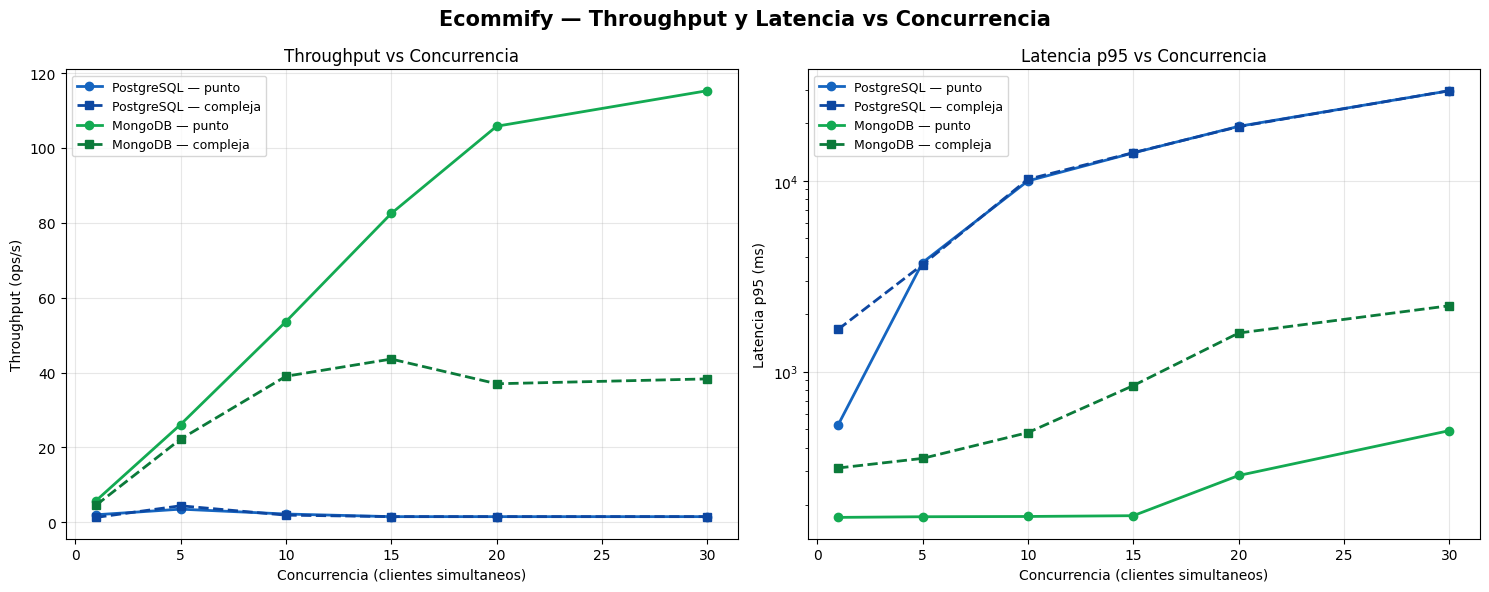

Guardado: /content/drive/MyDrive/Colab Notebooks/MaestriaArch-OBD-U5/evidencias/load_test_concurrencia_20260621_011737.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Ecommify — Throughput y Latencia vs Concurrencia', fontsize=15, fontweight='bold')

colores = {
    ('PostgreSQL', 'punto'): '#1565C0', ('PostgreSQL', 'compleja'): '#0D47A1',
    ('MongoDB', 'punto'): '#13AA52', ('MongoDB', 'compleja'): '#0B7A3A',
}
estilos = {'punto': '-o', 'compleja': '--s'}

for motor, tipo, _ in queries_a_probar:
    sub = df_concurrencia[(df_concurrencia['motor'] == motor) &
                          (df_concurrencia['tipo_query'] == tipo)].sort_values('concurrency')
    label = '{} — {}'.format(motor, tipo)
    axes[0].plot(sub['concurrency'], sub['throughput_ops_s'], estilos[tipo],
                color=colores[(motor, tipo)], label=label, linewidth=2, markersize=6)
    axes[1].plot(sub['concurrency'], sub['p95_ms'], estilos[tipo],
                color=colores[(motor, tipo)], label=label, linewidth=2, markersize=6)

axes[0].set_xlabel('Concurrencia (clientes simultaneos)')
axes[0].set_ylabel('Throughput (ops/s)')
axes[0].set_title('Throughput vs Concurrencia')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Concurrencia (clientes simultaneos)')
axes[1].set_ylabel('Latencia p95 (ms)')
axes[1].set_title('Latencia p95 vs Concurrencia')
axes[1].set_yscale('log')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
path1 = '/content/drive/MyDrive/Colab Notebooks/MaestriaArch-OBD-U5/evidencias/load_test_concurrencia_{}.png'.format(TIMESTAMP)
plt.savefig(path1, dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: ' + path1)

## 11. Grafica — Escalabilidad de dataset

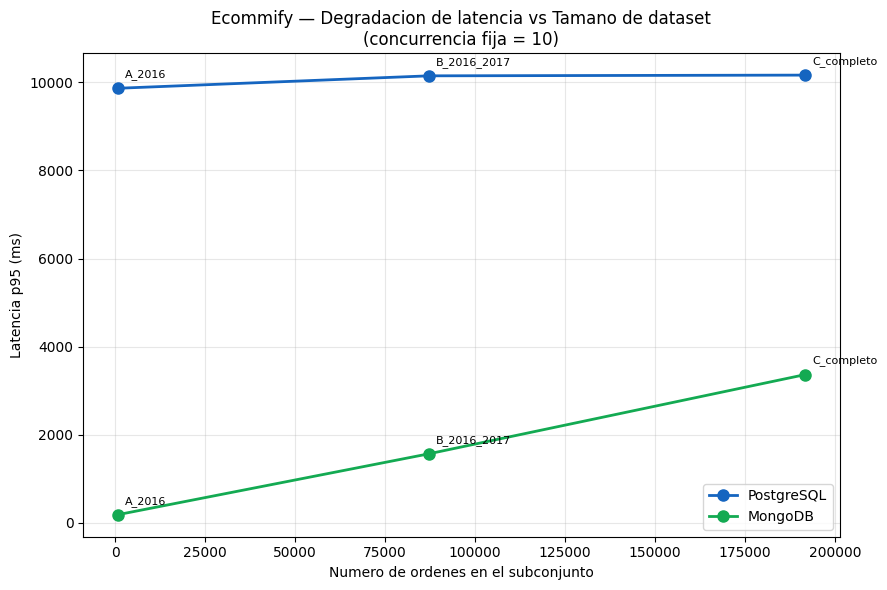

Guardado: /content/drive/MyDrive/Colab Notebooks/MaestriaArch-OBD-U5/evidencias/load_test_escalabilidad_20260621_011737.png


In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

merged = df_escalabilidad.merge(df_conteos, on='subconjunto')
merged = merged.sort_values('n_orders')

for motor, color in [('PostgreSQL', '#1565C0'), ('MongoDB', '#13AA52')]:
    sub = merged[merged['motor'] == motor]
    ax.plot(sub['n_orders'], sub['p95_ms'], '-o', color=color, label=motor,
            linewidth=2, markersize=8)
    for _, row in sub.iterrows():
        ax.annotate(row['subconjunto'], (row['n_orders'], row['p95_ms']),
                    textcoords='offset points', xytext=(5, 8), fontsize=8)

ax.set_xlabel('Numero de ordenes en el subconjunto')
ax.set_ylabel('Latencia p95 (ms)')
ax.set_title('Ecommify — Degradacion de latencia vs Tamano de dataset\n(concurrencia fija = {})'.format(CONCURRENCY_FIJA))
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
path2 = '/content/drive/MyDrive/Colab Notebooks/MaestriaArch-OBD-U5/evidencias/load_test_escalabilidad_{}.png'.format(TIMESTAMP)
plt.savefig(path2, dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: ' + path2)

## 12. Tabla comparativa consolidada

In [13]:
print('=== Tabla resumen: throughput y latencia a concurrencia=10 ===\n')
resumen = df_concurrencia[df_concurrencia['concurrency'] == 10][
    ['motor', 'tipo_query', 'throughput_ops_s', 'p50_ms', 'p95_ms', 'p99_ms', 'errors']
].reset_index(drop=True)
print(resumen.to_string(index=False))

print('\n=== Puntos de quiebre ===\n')
print(df_quiebre[['motor', 'tipo_query', 'concurrency', 'razon']].to_string(index=False))

print('\n=== Escalabilidad: variacion de p95 desde subconjunto mas chico al mas grande ===\n')
for motor in ['PostgreSQL', 'MongoDB']:
    sub = merged[merged['motor'] == motor].sort_values('n_orders')
    p95_chico = sub.iloc[0]['p95_ms']
    p95_grande = sub.iloc[-1]['p95_ms']
    factor = p95_grande / p95_chico if p95_chico else None
    print('  {}: {:.1f}ms ({:,} ordenes) -> {:.1f}ms ({:,} ordenes)  factor={:.2f}x'.format(
        motor, p95_chico, sub.iloc[0]['n_orders'], p95_grande, sub.iloc[-1]['n_orders'], factor))

=== Tabla resumen: throughput y latencia a concurrencia=10 ===

     motor tipo_query  throughput_ops_s  p50_ms   p95_ms   p99_ms  errors
PostgreSQL      punto               2.2 1643.92  9978.00 10129.05       0
PostgreSQL   compleja               1.9 8607.75 10179.84 10304.39       0
   MongoDB      punto              53.6  172.17   174.21   195.37       0
   MongoDB   compleja              39.0  225.04   479.16   610.28       0

=== Puntos de quiebre ===

     motor tipo_query  concurrency                                             razon
PostgreSQL      punto          5.0                        p95 > 3x baseline (1580ms)
PostgreSQL   compleja         10.0                        p95 > 3x baseline (4996ms)
   MongoDB      punto          NaN sin degradacion significativa en el rango probado
   MongoDB   compleja         20.0                         p95 > 3x baseline (938ms)

=== Escalabilidad: variacion de p95 desde subconjunto mas chico al mas grande ===

  PostgreSQL: 9867.1ms (638 o

## 13. Exportar evidencias (CSV + JSON + gráficas) y descargar

In [14]:
# CSVs
df_concurrencia.to_csv('/content/drive/MyDrive/Colab Notebooks/MaestriaArch-OBD-U5/evidencias/load_test_concurrencia_{}.csv'.format(TIMESTAMP), index=False)
df_escalabilidad.to_csv('/content/drive/MyDrive/Colab Notebooks/MaestriaArch-OBD-U5/evidencias/load_test_escalabilidad_{}.csv'.format(TIMESTAMP), index=False)
df_quiebre.to_csv('/content/drive/MyDrive/Colab Notebooks/MaestriaArch-OBD-U5/evidencias/puntos_quiebre_{}.csv'.format(TIMESTAMP), index=False)
df_conteos.to_csv('/content/drive/MyDrive/Colab Notebooks/MaestriaArch-OBD-U5/evidencias/conteos_subconjuntos_{}.csv'.format(TIMESTAMP), index=False)

# JSON consolidado (para uso programatico en el informe)
consolidado = {
    'timestamp': TIMESTAMP,
    'concurrencia': resultados_concurrencia,
    'escalabilidad': resultados_escalabilidad,
    'puntos_quiebre': puntos_quiebre,
    'conteos_subconjuntos': conteos_subconjunto,
    'config': {
        'concurrency_levels': CONCURRENCY_LEVELS,
        'duration_s_per_test': DURATION_S,
        'concurrency_fija_escalabilidad': CONCURRENCY_FIJA,
    }
}
with open('/content/drive/MyDrive/Colab Notebooks/MaestriaArch-OBD-U5/evidencias/load_test_consolidado_{}.json'.format(TIMESTAMP), 'w') as f:
    json.dump(consolidado, f, indent=2, default=str)

# README
readme = '''# Evidencias de Carga y Escalabilidad — Ecommify\n
Generado: {ts}\n
## Metodologia\n
Harness unico (ThreadPoolExecutor) reusado para PostgreSQL y MongoDB.\n
Cada punto de la matriz corre durante 10 segundos a concurrencia fija.\n
## Archivos\n
- load_test_concurrencia_{ts}.csv: throughput/latencia por nivel de concurrencia x motor x tipo de query\n
- load_test_escalabilidad_{ts}.csv: latencia por tamano de dataset (particiones 2016/2017/2018)\n
- puntos_quiebre_{ts}.csv: concurrencia donde aparece degradacion o errores\n
- conteos_subconjuntos_{ts}.csv: filas reales por subconjunto de escalabilidad\n
- load_test_consolidado_{ts}.json: todos los resultados crudos en JSON\n
- load_test_concurrencia_{ts}.png / load_test_escalabilidad_{ts}.png: graficas\n
'''.format(ts=TIMESTAMP)
with open('/content/drive/MyDrive/Colab Notebooks/MaestriaArch-OBD-U5/evidencias/README_load_testing_{}.md'.format(TIMESTAMP), 'w') as f:
    f.write(readme)

import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/Colab Notebooks/MaestriaArch-OBD-U5/evidencias/evidencias_load_testing.zip', 'w') as zf:
    for root, dirs, files in os.walk('/content/evidencias'):
        for file in files:
            if TIMESTAMP in file:
                zf.write(os.path.join(root, file), file)

from google.colab import files
files.download('/content/drive/MyDrive/Colab Notebooks/MaestriaArch-OBD-U5/evidencias/evidencias_load_testing.zip')
print('Evidencias descargadas: evidencias_load_testing.zip')
print('\nUsar estos archivos como input real para el Informe Tecnico Integral.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Evidencias descargadas: evidencias_load_testing.zip

Usar estos archivos como input real para el Informe Tecnico Integral.


## 14. Cierre de conexiones

In [15]:
PG_POOL.closeall()
MC.close()
print('Conexiones cerradas. Notebook 05 completado.')

Conexiones cerradas. Notebook 05 completado.
